In [1]:
# ========================================
# Cell 1: 导入必要的库 + 加载数据
# ========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 让 pandas 显示更多列，不然 81 列会被省略
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

# 设置 seaborn 默认风格
sns.set_style("whitegrid")

# 加载训练数据
train_df = pd.read_csv("train.csv")

# 基本信息
print(f"数据维度 (rows, cols): {train_df.shape}")
print(f"总样本数: {train_df.shape[0]}")
print(f"总特征数: {train_df.shape[1] - 1}  (扣除 Id 和 SalePrice)")
print("=" * 50)

# 查看前 5 行
train_df.head()

数据维度 (rows, cols): (1460, 81)
总样本数: 1460
总特征数: 80  (扣除 Id 和 SalePrice)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
# ========================================
# Cell 2: 数据类型 + 基本信息
# ========================================

# 看看有多少数值列、多少类别列
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = train_df.select_dtypes(include=['object']).columns

print(f"数值型特征 (numeric): {len(num_cols)} 个")
print(f"类别型特征 (categorical): {len(cat_cols)} 个")
print(f"总计: {len(num_cols) + len(cat_cols)} 列")
print("=" * 50)

# 详细信息（数据类型 + 非空数量）
train_df.info()

数值型特征 (numeric): 38 个
类别型特征 (categorical): 43 个
总计: 81 列
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 


SalePrice 统计摘要:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
--------------------------------------------------
偏度 (Skewness): 1.883
峰度 (Kurtosis): 6.536


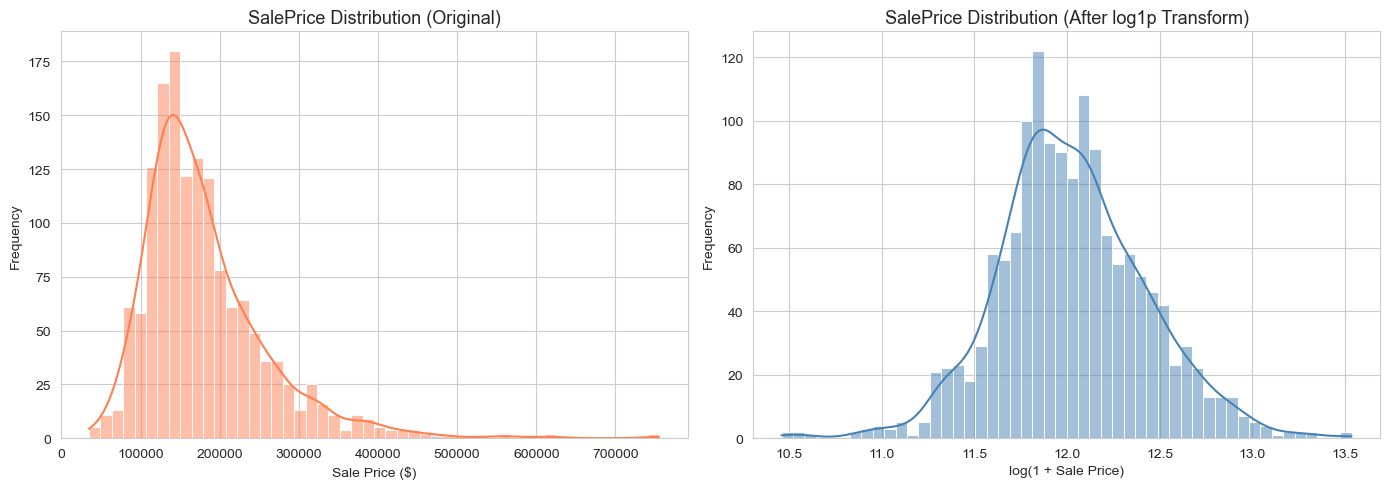


log 变换后的偏度: 0.121
→ 偏度从 ~1.88 降到接近 0，分布接近正态，这就是为什么我们要对 y 做 log 变换。


In [3]:
# ========================================
# Cell 3: 目标变量 SalePrice 分析
# ========================================

# 基础统计
print("SalePrice 统计摘要:")
print(train_df['SalePrice'].describe())
print("-" * 50)
print(f"偏度 (Skewness): {train_df['SalePrice'].skew():.3f}")
print(f"峰度 (Kurtosis): {train_df['SalePrice'].kurt():.3f}")

# 画两张图对比：原始分布 vs log 变换后的分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：原始 SalePrice 分布
sns.histplot(train_df['SalePrice'], bins=50, kde=True, ax=axes[0], color='coral')
axes[0].set_title('SalePrice Distribution (Original)', fontsize=13)
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')

# 右图：log1p 变换后的分布
sns.histplot(np.log1p(train_df['SalePrice']), bins=50, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('SalePrice Distribution (After log1p Transform)', fontsize=13)
axes[1].set_xlabel('log(1 + Sale Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"\nlog 变换后的偏度: {np.log1p(train_df['SalePrice']).skew():.3f}")
print("→ 偏度从 ~1.88 降到接近 0，分布接近正态，这就是为什么我们要对 y 做 log 变换。")

共有 19 列存在缺失值

              MissingCount  MissingRatio(%)
PoolQC                1453            99.52
MiscFeature           1406            96.30
Alley                 1369            93.77
Fence                 1179            80.75
MasVnrType             872            59.73
FireplaceQu            690            47.26
LotFrontage            259            17.74
GarageType              81             5.55
GarageYrBlt             81             5.55
GarageFinish            81             5.55
GarageQual              81             5.55
GarageCond              81             5.55
BsmtExposure            38             2.60
BsmtFinType2            38             2.60
BsmtQual                37             2.53
BsmtCond                37             2.53
BsmtFinType1            37             2.53
MasVnrArea               8             0.55
Electrical               1             0.07


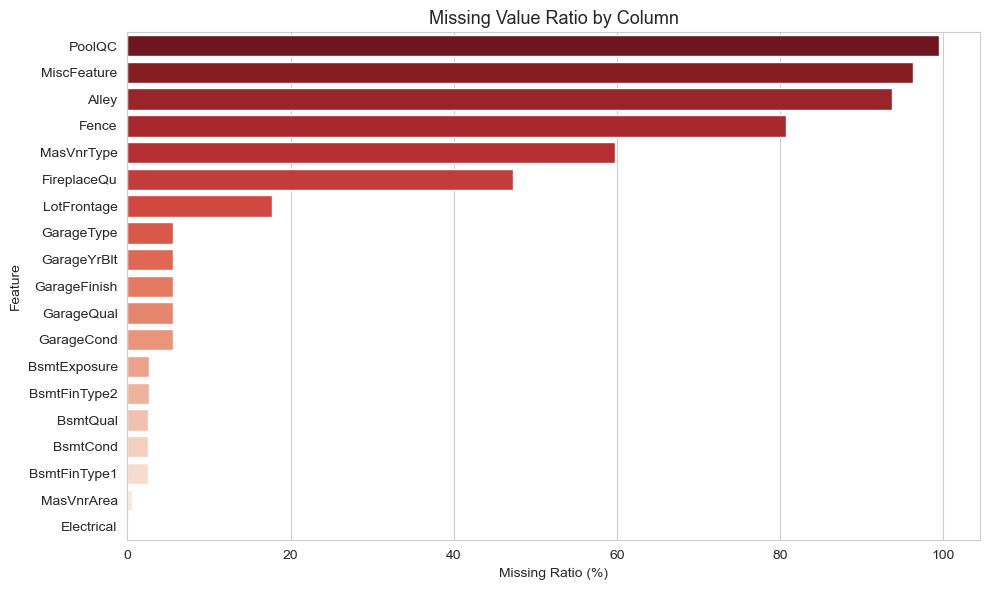

In [4]:
# ========================================
# Cell 4: 缺失值概览
# ========================================

# 计算每列缺失率
missing_count = train_df.isnull().sum()
missing_ratio = (missing_count / len(train_df)) * 100

# 只保留有缺失的列，按缺失率降序
missing_df = pd.DataFrame({
    'MissingCount': missing_count,
    'MissingRatio(%)': missing_ratio.round(2)
})
missing_df = missing_df[missing_df['MissingCount'] > 0].sort_values(
    by='MissingRatio(%)', ascending=False
)

print(f"共有 {len(missing_df)} 列存在缺失值\n")
print(missing_df)

# 可视化：缺失率条形图
plt.figure(figsize=(10, 6))
sns.barplot(
    x=missing_df['MissingRatio(%)'],
    y=missing_df.index,
    palette='Reds_r',
    hue=missing_df.index,
    legend=False
)
plt.title('Missing Value Ratio by Column', fontsize=13)
plt.xlabel('Missing Ratio (%)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

与 SalePrice 相关性最高的 15 个数值特征：

SalePrice       1.000
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
GarageYrBlt     0.486
MasVnrArea      0.477
Fireplaces      0.467
BsmtFinSF1      0.386
Name: SalePrice, dtype: float64


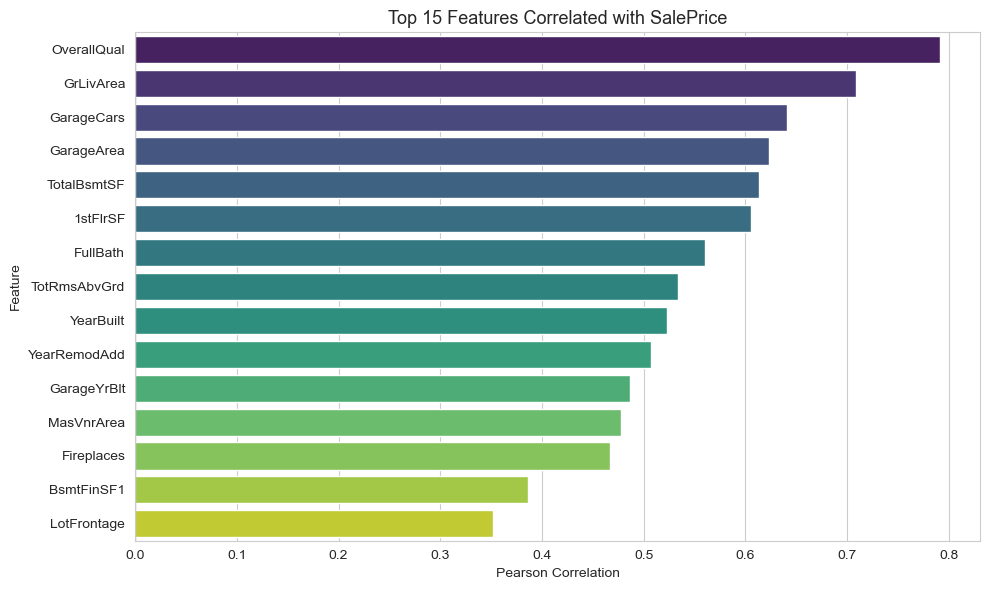

In [5]:
# ========================================
# Cell 5: 数值特征相关性分析
# ========================================

# 计算所有数值列与 SalePrice 的皮尔逊相关系数
numeric_df = train_df.select_dtypes(include=['int64', 'float64'])
corr_with_price = numeric_df.corr()['SalePrice'].sort_values(ascending=False)

# 打印 Top 15 相关特征
print("与 SalePrice 相关性最高的 15 个数值特征：\n")
print(corr_with_price.head(15).round(3))

# 画前 15 个特征的相关性条形图
top15 = corr_with_price.drop('SalePrice').head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top15.values,
    y=top15.index,
    palette='viridis',
    hue=top15.index,
    legend=False
)
plt.title('Top 15 Features Correlated with SalePrice', fontsize=13)
plt.xlabel('Pearson Correlation')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Block 1 小结

先摸了一下数据的底。一共 1460 条房屋数据，81 列，除掉 Id 和 SalePrice 之后还有 79 个特征。数值型和类别型差不多一半一半（38 个 vs 43 个），所以后面处理缺失值的时候要分开想。

**关于目标变量 SalePrice**

原始价格分布很偏，偏度 1.88，从直方图上看就是一条长尾——大部分房子在 15 万左右，但有少数豪宅能到 70 多万，把尾巴拉得很长。这种分布不适合直接拿来做线性回归，因为模型会被高价房带偏。

做了个 log1p 变换之后偏度降到 0.12，分布基本就是钟形了，符合线性模型对正态性的假设。所以后面建模的时候 y 统一用 log(1 + SalePrice)，最后评估再还原回原始价格。

**关于缺失值**

有 19 列有缺失，缺失率差异巨大。最夸张的是 PoolQC（99.5%）、MiscFeature（96%）、Alley（94%）、Fence（81%）。

但这里有个重要的观察：这些"缺失"其实不是数据丢了，而是**这栋房子本来就没有**这个东西。比如 PoolQC 缺失就是"没泳池"、Alley 缺失就是"没小巷"。看到 Garage 那一组 5 列的缺失率**一模一样都是 5.55%**，就更能确认了——这 81 套房子根本没车库。Basement 那一组也是一样的情况（都是 2.5% 左右）。

所以下一个 Block 处理缺失值的时候不能一股脑填中位数或众数，要分情况：
- 这种"没有此设施"的，填 "None" 当成一个独立类别
- 真正的数据缺失（比如 Electrical 只缺 1 个），才用众数填
- LotFrontage 缺 17.7% 这种比较尴尬的，要再想办法

**关于强相关特征**

先看一眼哪些数值特征和房价关系最紧密：

- OverallQual（整体品质）：0.79
- GrLivArea（居住面积）：0.71
- GarageCars / GarageArea：0.64 / 0.62
- TotalBsmtSF（地下室面积）：0.61

基本上就是"品质 + 面积"两件事主导房价，符合常识。这几个特征后面在 Lasso、Ridge、Gradient Boosting 里大概率都会是 Top，等建完模再验证。

In [6]:
# ========================================
# Cell 6: 准备工作 - 复制数据 + 分离 y
# ========================================

# 复制一份，避免污染原始 train_df（方便后面回头对比）
df = train_df.copy()

# 分离目标变量：对 SalePrice 做 log1p 变换
y = np.log1p(df['SalePrice'])

# X 先移除 SalePrice 和 Id（Id 是标识符，无预测价值）
X = df.drop(columns=['SalePrice', 'Id'])

print(f"X 形状: {X.shape}")
print(f"y 形状: {y.shape}")
print(f"y 范围: [{y.min():.3f}, {y.max():.3f}]  (log 空间)")
print(f"y 均值: {y.mean():.3f}, 标准差: {y.std():.3f}")

X 形状: (1460, 79)
y 形状: (1460,)
y 范围: [10.460, 13.534]  (log 空间)
y 均值: 12.024, 标准差: 0.399


In [7]:
# ========================================
# Cell 7: 数值列缺失值处理
# ========================================

# 先看看哪些数值列有缺失
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
num_missing = X[num_cols].isnull().sum()
num_missing = num_missing[num_missing > 0].sort_values(ascending=False)

print("数值列缺失情况：")
print(num_missing)
print("-" * 50)

# ---- 策略 1: LotFrontage - 按邻居分组中位数 ----
# 同一个 Neighborhood 的房子临街宽度更接近，比全局中位数更准
X['LotFrontage'] = X.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# ---- 策略 2: GarageYrBlt - 填 0 ----
# 这列缺失代表"没有车库"，没有年份。填 0 当作特殊标记
X['GarageYrBlt'] = X['GarageYrBlt'].fillna(0)

# ---- 策略 3: MasVnrArea - 填 0 ----
# 这列缺失代表"没有砖石外墙"，面积自然是 0
X['MasVnrArea'] = X['MasVnrArea'].fillna(0)

# 检查是否还有数值列缺失
remaining = X[num_cols].isnull().sum().sum()
print(f"处理后剩余数值列缺失: {remaining}")
print("数值列缺失处理完成 ✓")

数值列缺失情况：
LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64
--------------------------------------------------
处理后剩余数值列缺失: 0
数值列缺失处理完成 ✓


In [8]:
# ========================================
# Cell 8: 类别列缺失诊断
# ========================================

cat_cols = X.select_dtypes(include=['object']).columns
cat_missing = X[cat_cols].isnull().sum()
cat_missing = cat_missing[cat_missing > 0].sort_values(ascending=False)

print(f"有缺失的类别列: {len(cat_missing)} 个\n")

# 对每个缺失类别列做诊断报告
diagnosis = []
for col in cat_missing.index:
    miss_ratio = cat_missing[col] / len(X) * 100
    value_counts = X[col].value_counts(normalize=True)
    top1_ratio = value_counts.iloc[0] * 100 if len(value_counts) > 0 else 0
    top1_value = value_counts.index[0] if len(value_counts) > 0 else 'N/A'
    
    diagnosis.append({
        'Column': col,
        'Missing%': round(miss_ratio, 2),
        'TopValue': top1_value,
        'TopRatio%': round(top1_ratio, 2)
    })

diag_df = pd.DataFrame(diagnosis)
print(diag_df.to_string(index=False))

有缺失的类别列: 16 个

      Column  Missing% TopValue  TopRatio%
      PoolQC     99.52       Gd      42.86
 MiscFeature     96.30     Shed      90.74
       Alley     93.77     Grvl      54.95
       Fence     80.75    MnPrv      55.87
  MasVnrType     59.73  BrkFace      75.68
 FireplaceQu     47.26       Gd      49.35
GarageFinish      5.55      Unf      43.87
  GarageQual      5.55       TA      95.07
  GarageType      5.55   Attchd      63.09
  GarageCond      5.55       TA      96.16
BsmtExposure      2.60       No      67.02
BsmtFinType2      2.60      Unf      88.33
    BsmtQual      2.53       TA      45.61
BsmtFinType1      2.53      Unf      30.22
    BsmtCond      2.53       TA      92.13
  Electrical      0.07    SBrkr      91.43


In [9]:
# ========================================
# Cell 9: 类别列缺失值填充
# ========================================

# ---- 策略 1: 填 "None" —— 代表"没有此设施" ----
# 这些列的缺失是结构性的（房子本来就没有泳池/车库/地下室等）
none_fill_cols = [
    # 泳池、小巷、围栏、杂项设施
    'PoolQC', 'MiscFeature', 'Alley', 'Fence',
    # 砖石外墙类型
    'MasVnrType',
    # 壁炉质量
    'FireplaceQu',
    # 车库四兄弟
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    # 地下室五兄弟
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
]

for col in none_fill_cols:
    X[col] = X[col].fillna("None")

print(f"已用 'None' 填充 {len(none_fill_cols)} 列")

# ---- 策略 2: 填众数 —— 真正的数据缺失 ----
# Electrical 只缺 1 个，91% 的房子是 SBrkr，放心填众数
mode_fill_cols = ['Electrical']

for col in mode_fill_cols:
    most_common = X[col].mode()[0]
    X[col] = X[col].fillna(most_common)
    print(f"  {col}: 用众数 '{most_common}' 填充")

# ---- 最终检查 ----
total_missing = X.isnull().sum().sum()
print(f"\n处理后全表剩余缺失值: {total_missing}")
if total_missing == 0:
    print("✓ 所有缺失值处理完成")
else:
    print("⚠ 还有列存在缺失，需要检查")
    print(X.isnull().sum()[X.isnull().sum() > 0])

已用 'None' 填充 15 列
  Electrical: 用众数 'SBrkr' 填充

处理后全表剩余缺失值: 0
✓ 所有缺失值处理完成


In [10]:
# ========================================
# Cell 10: 有序类别编码 + One-Hot 编码
# ========================================

# ---- 策略 1: 有序类别映射 ----
# 这些列的值之间有明确的好坏顺序，应该编码成数字而不是 One-Hot
# Ex (Excellent) > Gd (Good) > TA (Typical/Average) > Fa (Fair) > Po (Poor) > None

quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

ordinal_quality_cols = [
    'ExterQual', 'ExterCond',           # 外墙质量/状况
    'BsmtQual', 'BsmtCond',             # 地下室质量/状况
    'HeatingQC',                         # 供暖质量
    'KitchenQual',                       # 厨房质量
    'FireplaceQu',                       # 壁炉质量
    'GarageQual', 'GarageCond',         # 车库质量/状况
    'PoolQC',                            # 泳池质量
]

for col in ordinal_quality_cols:
    if col in X.columns:
        X[col] = X[col].map(quality_map)

print(f"已对 {len(ordinal_quality_cols)} 个有序质量列做数字映射 (Ex=5 ... Po=1, None=0)")

# 其他几个有特定顺序的类别列
# BsmtExposure: Gd > Av > Mn > No > None
X['BsmtExposure'] = X['BsmtExposure'].map(
    {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
)

# BsmtFinType1/2: GLQ > ALQ > BLQ > Rec > LwQ > Unf > None
bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
X['BsmtFinType1'] = X['BsmtFinType1'].map(bsmt_fin_map)
X['BsmtFinType2'] = X['BsmtFinType2'].map(bsmt_fin_map)

# GarageFinish: Fin > RFn > Unf > None
X['GarageFinish'] = X['GarageFinish'].map(
    {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
)

print("已对 BsmtExposure / BsmtFinType1 / BsmtFinType2 / GarageFinish 做顺序映射")
print("-" * 50)

# ---- 策略 2: 其余类别列走 One-Hot ----
# 此时剩下的类别列都是"无顺序的名义类别"（如 Neighborhood、RoofStyle）
before_cols = X.shape[1]
X = pd.get_dummies(X, drop_first=True)
after_cols = X.shape[1]

print(f"One-Hot 编码前: {before_cols} 列")
print(f"One-Hot 编码后: {after_cols} 列")
print(f"展开后新增 {after_cols - before_cols} 列")
print(f"\n最终 X 形状: {X.shape}")

已对 10 个有序质量列做数字映射 (Ex=5 ... Po=1, None=0)
已对 BsmtExposure / BsmtFinType1 / BsmtFinType2 / GarageFinish 做顺序映射
--------------------------------------------------
One-Hot 编码前: 79 列
One-Hot 编码后: 214 列
展开后新增 135 列

最终 X 形状: (1460, 214)


In [11]:
# ========================================
# Cell 11: Block 2 收尾检查
# ========================================

print("=" * 60)
print(" Block 2 处理完成总结")
print("=" * 60)
print(f"✓ 特征矩阵 X: {X.shape}")
print(f"✓ 目标变量 y: {y.shape}")
print(f"✓ 缺失值总数: {X.isnull().sum().sum()}")
print(f"✓ 数据类型分布:")
print(X.dtypes.value_counts())
print("-" * 60)

# 快速确认 X 里没有无穷大或 NaN（建模前的安全检查）
print(f"X 中是否含 NaN: {X.isnull().any().any()}")
print(f"X 中是否含 inf: {np.isinf(X.select_dtypes(include=['number'])).any().any()}")
print(f"y 中是否含 NaN: {y.isnull().any()}")

# 看看 X 的前几行确认样子正常
print("\nX 前 3 行预览（前 10 列）：")
X.iloc[:3, :10]

 Block 2 处理完成总结
✓ 特征矩阵 X: (1460, 214)
✓ 目标变量 y: (1460,)
✓ 缺失值总数: 0
✓ 数据类型分布:
bool       164
int64       47
float64      3
Name: count, dtype: int64
------------------------------------------------------------
X 中是否含 NaN: False
X 中是否含 inf: False
y 中是否含 NaN: False

X 前 3 行预览（前 10 列）：


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond
0,60,65.0,8450,7,5,2003,2003,196.0,4,3
1,20,80.0,9600,6,8,1976,1976,0.0,3,3
2,60,68.0,11250,7,5,2001,2002,162.0,4,3


## Block 2 小结

这块把数据整理干净，最终拿到一个 1460 × 214 的干净特征矩阵，零缺失。

**y 的处理：** 对 SalePrice 做了 log1p 变换，log 空间的 y 范围是 [10.46, 13.53]，均值 12.02，标准差 0.40。后面所有模型都用这个 y 训练，评估再还原。

**缺失值分三种处理：**

1. **结构性缺失 —— 填 None 或 0（15 个类别列 + 2 个数值列）**
   
   PoolQC、Alley、Fence、MiscFeature 这四列缺失率都超过 80%，还有 FireplaceQu（47%）、MasVnrType（60%），以及 Garage 四兄弟（都缺 5.55%）、Basement 五兄弟（都缺 2.5%）。这些"缺失"其实是"这房子本来就没有"，所以类别列填 "None"、数值列 GarageYrBlt 和 MasVnrArea 填 0。

2. **真实缺失 —— 填众数（1 个）**
   
   Electrical 只缺 1 个，而且 91% 的房子都是 SBrkr，直接用众数填。

3. **上下文相关 —— 按分组中位数（1 个）**
   
   LotFrontage 缺 259 个（17.7%）。这个比例用全局中位数太糙，所以按 Neighborhood 分组填中位数——同一个社区的临街宽度更接近。

**编码这里做了一点细致的区分：**

Ames 数据里很多类别列其实是有顺序的，比如 ExterQual、KitchenQual、HeatingQC 这些值是 Ex/Gd/TA/Fa/Po 五档评级。如果直接 One-Hot，模型就丢失了"越高越好"的顺序信息。

所以：
- **10 个质量列**（ExterQual、BsmtQual、HeatingQC、KitchenQual 等）映射成 Ex=5, Gd=4, TA=3, Fa=2, Po=1, None=0
- **4 个其他有序列**（BsmtExposure、BsmtFinType1/2、GarageFinish）按各自的顺序单独映射
- **剩下的无序类别列**（Neighborhood、RoofStyle、SaleType 等）才走 One-Hot

**最终结果：**
- 79 列 → 214 列（One-Hot 展开新增 135 列）
- 数据类型：164 列 bool（One-Hot 出来的）+ 47 列 int + 3 列 float
- 缺失值 0，无 NaN 无 inf，可以进下一步建模

In [12]:
# ========================================
# Cell 12: 数据划分
# ========================================
from sklearn.model_selection import train_test_split, KFold

# 把数据分成两块：
#   - X_dev / y_dev: 80% 用来做所有的 CV、调参、模型选择
#   - X_test / y_test: 20% 锁起来，最后一步才用来做"期末考试"
# 这样评估出来的 test RMSE 才是真实泛化能力的反映
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Dev set   (用于 CV 和调参): {X_dev.shape}, y: {y_dev.shape}")
print(f"Final test (锁起来最后用) : {X_test.shape}, y: {y_test.shape}")
print(f"Dev / Test 比例: {len(X_dev)/len(X):.0%} / {len(X_test)/len(X):.0%}")

Dev set   (用于 CV 和调参): (1168, 214), y: (1168,)
Final test (锁起来最后用) : (292, 214), y: (292,)
Dev / Test 比例: 80% / 20%


In [13]:
# ========================================
# Cell 13: 评估工具 - RMSE 函数 + K-Fold
# ========================================
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

# 我们的 y 是 log 空间的，直接在 log 空间算 RMSE 就行
# （Kaggle 比赛官方评估指标就是 log 空间的 RMSE）
def rmse(y_true, y_pred):
    """在 log 空间计算 RMSE"""
    return np.sqrt(mean_squared_error(y_true, y_pred))

# 5-Fold 交叉验证规则
# shuffle=True 先洗牌再切，避免数据有隐藏顺序
# random_state=42 保证每次 fold 切法一样，模型间可比
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("✓ rmse() 函数已定义 (log 空间)")
print("✓ 5-Fold KFold 已设置 (shuffle=True, random_state=42)")
print("\n说明：")
print("  - 所有模型都用这同一个 kfold，保证公平比较")
print("  - RMSE 在 log 空间计算，越小越好")
print("  - Kaggle 官方评估指标：log(SalePrice) 的 RMSE")

✓ rmse() 函数已定义 (log 空间)
✓ 5-Fold KFold 已设置 (shuffle=True, random_state=42)

说明：
  - 所有模型都用这同一个 kfold，保证公平比较
  - RMSE 在 log 空间计算，越小越好
  - Kaggle 官方评估指标：log(SalePrice) 的 RMSE


In [14]:
# ========================================
# Cell 14: Baseline Linear Regression (CV 分数)
# ========================================
from sklearn.linear_model import LinearRegression

# 最朴素的线性回归，没有任何正则化
linreg = LinearRegression()

# 在 dev set 上做 5-Fold CV
# scoring='neg_mean_squared_error' —— sklearn 约定越大越好，所以 MSE 要取负
# 我们后面再手动变回来
cv_scores = cross_val_score(
    linreg, X_dev, y_dev,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

# 把 neg_MSE 转成 RMSE
cv_rmse = np.sqrt(-cv_scores)

print("=" * 50)
print("  Baseline Linear Regression (5-Fold CV)")
print("=" * 50)
for i, score in enumerate(cv_rmse):
    print(f"  Fold {i+1} RMSE: {score:.4f}")
print("-" * 50)
print(f"  平均 RMSE: {cv_rmse.mean():.4f}")
print(f"  标准差:    {cv_rmse.std():.4f}")
print("=" * 50)

# 存下来，后面对比用
baseline_cv_rmse = cv_rmse.mean()

  Baseline Linear Regression (5-Fold CV)
  Fold 1 RMSE: 0.1356
  Fold 2 RMSE: 0.1694
  Fold 3 RMSE: 0.2572
  Fold 4 RMSE: 0.1334
  Fold 5 RMSE: 0.1524
--------------------------------------------------
  平均 RMSE: 0.1696
  标准差:    0.0457


In [15]:
# ========================================
# Cell 15: Baseline 在 Final Test 上的表现
# ========================================

# 用整个 dev set 重新训练一次（不切 fold）
linreg_final = LinearRegression()
linreg_final.fit(X_dev, y_dev)

# 在 final test 上预测
y_pred_test = linreg_final.predict(X_test)

# 计算 final test RMSE（log 空间）
baseline_test_rmse = rmse(y_test, y_pred_test)

# 顺便换算回"大致百分比误差"方便直观理解
baseline_pct_error = (np.exp(baseline_test_rmse) - 1) * 100

print("=" * 50)
print("  Baseline Linear Regression - Final Test")
print("=" * 50)
print(f"  Test RMSE (log 空间):  {baseline_test_rmse:.4f}")
print(f"  约等于百分比误差:       {baseline_pct_error:.2f}%")
print("=" * 50)
print("\n备注：test RMSE 比 CV 平均分更可靠地反映泛化能力，")
print("     因为 final test 是模型完全没见过的数据。")

  Baseline Linear Regression - Final Test
  Test RMSE (log 空间):  0.2055
  约等于百分比误差:       22.81%

备注：test RMSE 比 CV 平均分更可靠地反映泛化能力，
     因为 final test 是模型完全没见过的数据。


## Block 3 小结

这块是建模的起点，做了数据划分、设置评估规则、跑了 baseline。

**数据划分策略：**
把全部 1460 条数据切成两块——80% (1168 条) 做 dev set，20% (292 条) 做 final test。后面所有的 CV、调参、模型对比都只在 dev set 上做，final test 完全锁住，只在最后一步用来评估"真实泛化能力"。`random_state=42` 保证划分可复现。

**评估规则：**
- RMSE 在 **log 空间**计算，和 Kaggle 官方评估指标一致
- 5-Fold KFold，shuffle=True，random_state=42
- 所有模型都复用同一个 kfold 对象，保证公平对比

**Baseline: Linear Regression**

朴素线性回归，没有任何正则化。跑完结果：

| 指标 | 值 |
|---|---|
| CV RMSE (5 fold 平均) | 0.1696 |
| CV RMSE 标准差 | 0.0457 |
| Final Test RMSE | 0.2055 |
| 约等于百分比误差 | 22.81% |

5 个 fold 的 RMSE 分别是 0.1356 / 0.1694 / **0.2572** / 0.1334 / 0.1524，最差的 Fold 3 显著偏高，5 折差距接近 2 倍，说明模型对训练集切法很敏感——**这是典型的过拟合征兆**。

Test RMSE (0.2055) 比 CV 平均 (0.1696) 差 0.036，也印证了过拟合：模型在 CV 时见过相似数据，到真正没见过的 final test 上表现就掉下来了。

**为什么会过拟合？**

我们有 214 列特征但只有 1168 个训练样本，特征数接近样本数 1/5，线性回归在这种高维场景下非常容易把噪音当信号学进去。

**下一步**用 Lasso 和 Ridge 加入正则化，应该能明显改善这个问题——正则化会强制模型把不重要的特征压小或归零。baseline 的分数 (0.1696 CV / 0.2055 Test) 就是后面所有模型要打败的目标。

In [16]:
# ========================================
# Cell 16: 特征标准化 + 首次 Lasso 试跑
# ========================================
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge

# 标准化：让每列均值 0、方差 1
# 重要：fit 在 X_dev 上，transform 应用到 X_dev 和 X_test
scaler = StandardScaler()
X_dev_scaled = scaler.fit_transform(X_dev)
X_test_scaled = scaler.transform(X_test)

# 转回 DataFrame，保留列名（后面分析特征重要性要用）
X_dev_scaled = pd.DataFrame(X_dev_scaled, columns=X_dev.columns, index=X_dev.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"X_dev_scaled 形状: {X_dev_scaled.shape}")
print(f"X_test_scaled 形状: {X_test_scaled.shape}")
print(f"标准化后前 3 列的均值（应接近 0）: {X_dev_scaled.iloc[:, :3].mean().values.round(4)}")
print(f"标准化后前 3 列的方差（应接近 1）: {X_dev_scaled.iloc[:, :3].std().values.round(4)}")

# 试跑一个 Lasso（alpha=0.001，先看看能不能 work）
lasso_test = Lasso(alpha=0.001, max_iter=20000)
cv_scores = cross_val_score(
    lasso_test, X_dev_scaled, y_dev,
    cv=kfold, scoring='neg_mean_squared_error'
)
cv_rmse = np.sqrt(-cv_scores)
print(f"\nLasso(alpha=0.001) CV RMSE: {cv_rmse.mean():.4f} (±{cv_rmse.std():.4f})")

X_dev_scaled 形状: (1168, 214)
X_test_scaled 形状: (292, 214)
标准化后前 3 列的均值（应接近 0）: [ 0. -0.  0.]
标准化后前 3 列的方差（应接近 1）: [1.0004 1.0004 1.0004]

Lasso(alpha=0.001) CV RMSE: 0.1487 (±0.0332)


正在搜索 Lasso 最佳 alpha（共 40 个候选）...

✓ 最佳 alpha: 0.00273
✓ 对应 CV RMSE: 0.1467


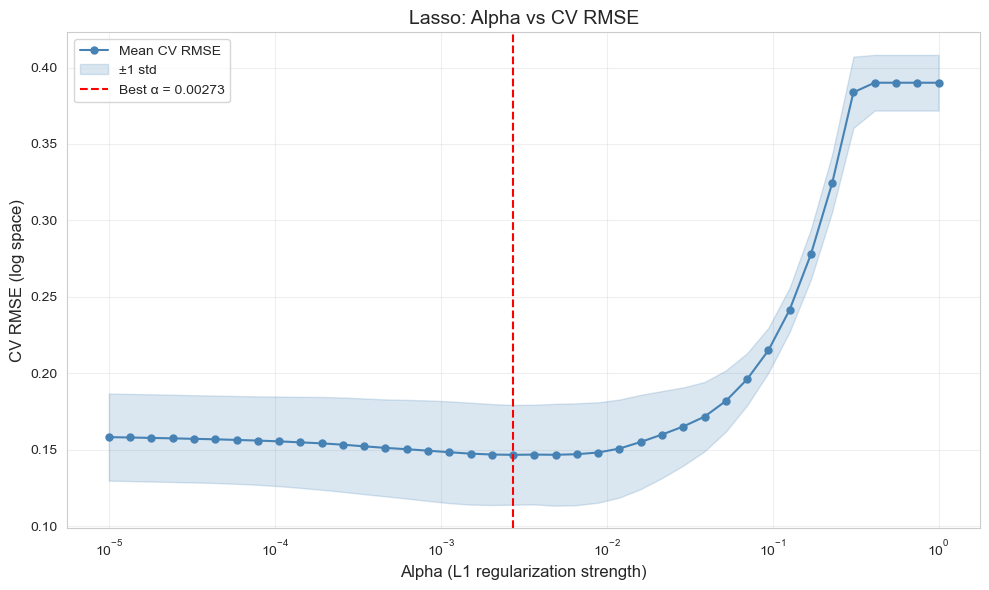

In [17]:
# ========================================
# Cell 17: Lasso alpha 搜索 + 画曲线
# ========================================

# 在对数空间上均匀取 40 个 alpha 值
# Lasso 对 alpha 敏感，需要细一点的搜索
lasso_alphas = np.logspace(-5, 0, 40)

lasso_cv_rmse_list = []
lasso_cv_std_list = []

print(f"正在搜索 Lasso 最佳 alpha（共 {len(lasso_alphas)} 个候选）...")
for alpha in lasso_alphas:
    model = Lasso(alpha=alpha, max_iter=20000)
    scores = cross_val_score(
        model, X_dev_scaled, y_dev,
        cv=kfold, scoring='neg_mean_squared_error'
    )
    rmse_scores = np.sqrt(-scores)
    lasso_cv_rmse_list.append(rmse_scores.mean())
    lasso_cv_std_list.append(rmse_scores.std())

lasso_cv_rmse_arr = np.array(lasso_cv_rmse_list)
lasso_cv_std_arr = np.array(lasso_cv_std_list)

# 找到最佳 alpha
best_idx = np.argmin(lasso_cv_rmse_arr)
best_alpha_lasso = lasso_alphas[best_idx]
best_rmse_lasso = lasso_cv_rmse_arr[best_idx]

print(f"\n✓ 最佳 alpha: {best_alpha_lasso:.5f}")
print(f"✓ 对应 CV RMSE: {best_rmse_lasso:.4f}")

# 画图：alpha vs RMSE（带误差带）
plt.figure(figsize=(10, 6))
plt.plot(lasso_alphas, lasso_cv_rmse_arr, 
         marker='o', markersize=5, color='steelblue', label='Mean CV RMSE')
plt.fill_between(lasso_alphas, 
                 lasso_cv_rmse_arr - lasso_cv_std_arr,
                 lasso_cv_rmse_arr + lasso_cv_std_arr,
                 alpha=0.2, color='steelblue', label='±1 std')
plt.axvline(x=best_alpha_lasso, color='red', linestyle='--', 
            label=f'Best α = {best_alpha_lasso:.5f}')
plt.xscale('log')
plt.xlabel('Alpha (L1 regularization strength)', fontsize=12)
plt.ylabel('CV RMSE (log space)', fontsize=12)
plt.title('Lasso: Alpha vs CV RMSE', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

正在搜索 Ridge 最佳 alpha（共 40 个候选）...

✓ 最佳 alpha: 412.4626
✓ 对应 CV RMSE: 0.1429


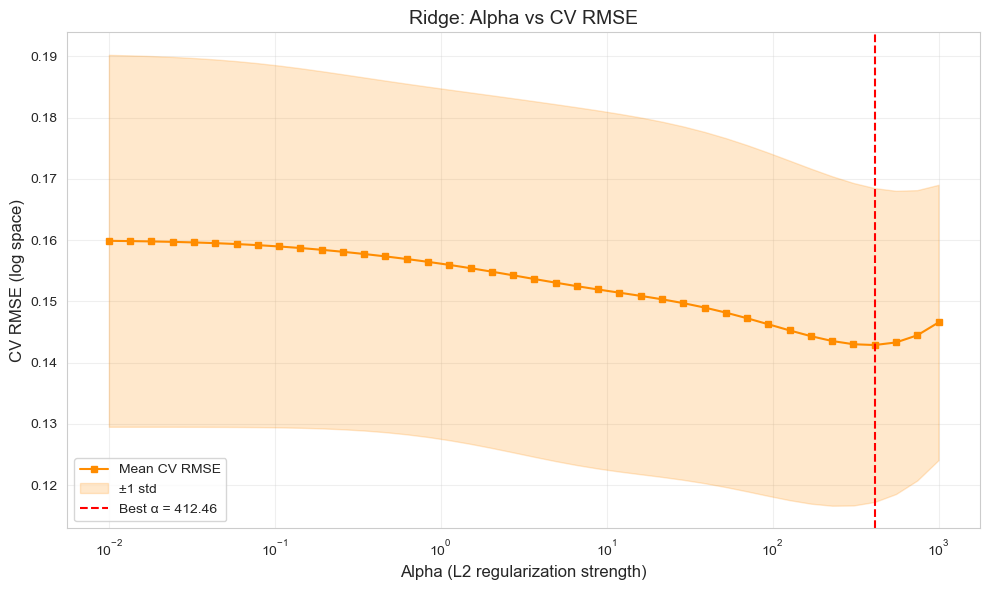

In [18]:
# ========================================
# Cell 18: Ridge alpha 搜索 + 画曲线
# ========================================

# Ridge 的 alpha 范围通常比 Lasso 大得多
ridge_alphas = np.logspace(-2, 3, 40)

ridge_cv_rmse_list = []
ridge_cv_std_list = []

print(f"正在搜索 Ridge 最佳 alpha（共 {len(ridge_alphas)} 个候选）...")
for alpha in ridge_alphas:
    model = Ridge(alpha=alpha)
    scores = cross_val_score(
        model, X_dev_scaled, y_dev,
        cv=kfold, scoring='neg_mean_squared_error'
    )
    rmse_scores = np.sqrt(-scores)
    ridge_cv_rmse_list.append(rmse_scores.mean())
    ridge_cv_std_list.append(rmse_scores.std())

ridge_cv_rmse_arr = np.array(ridge_cv_rmse_list)
ridge_cv_std_arr = np.array(ridge_cv_std_list)

# 找到最佳 alpha
best_idx = np.argmin(ridge_cv_rmse_arr)
best_alpha_ridge = ridge_alphas[best_idx]
best_rmse_ridge = ridge_cv_rmse_arr[best_idx]

print(f"\n✓ 最佳 alpha: {best_alpha_ridge:.4f}")
print(f"✓ 对应 CV RMSE: {best_rmse_ridge:.4f}")

# 画图
plt.figure(figsize=(10, 6))
plt.plot(ridge_alphas, ridge_cv_rmse_arr,
         marker='s', markersize=5, color='darkorange', label='Mean CV RMSE')
plt.fill_between(ridge_alphas,
                 ridge_cv_rmse_arr - ridge_cv_std_arr,
                 ridge_cv_rmse_arr + ridge_cv_std_arr,
                 alpha=0.2, color='darkorange', label='±1 std')
plt.axvline(x=best_alpha_ridge, color='red', linestyle='--',
            label=f'Best α = {best_alpha_ridge:.2f}')
plt.xscale('log')
plt.xlabel('Alpha (L2 regularization strength)', fontsize=12)
plt.ylabel('CV RMSE (log space)', fontsize=12)
plt.title('Ridge: Alpha vs CV RMSE', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# ========================================
# Cell 19: 最佳 Lasso / Ridge 在 Final Test 上的表现
# ========================================

# --- 用最佳 alpha 重新训练 Lasso ---
lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=20000)
lasso_best.fit(X_dev_scaled, y_dev)
lasso_test_pred = lasso_best.predict(X_test_scaled)
lasso_test_rmse = rmse(y_test, lasso_test_pred)

# --- 用最佳 alpha 重新训练 Ridge ---
ridge_best = Ridge(alpha=best_alpha_ridge)
ridge_best.fit(X_dev_scaled, y_dev)
ridge_test_pred = ridge_best.predict(X_test_scaled)
ridge_test_rmse = rmse(y_test, ridge_test_pred)

# --- 汇总对比表 ---
summary = pd.DataFrame({
    'Model':      ['Baseline LR',    'Lasso',             'Ridge'],
    'Best Alpha': ['—',              f'{best_alpha_lasso:.5f}',  f'{best_alpha_ridge:.2f}'],
    'CV RMSE':    [baseline_cv_rmse, best_rmse_lasso,     best_rmse_ridge],
    'Test RMSE':  [baseline_test_rmse, lasso_test_rmse,   ridge_test_rmse],
    'Pct Error':  [f'{(np.exp(baseline_test_rmse)-1)*100:.2f}%',
                   f'{(np.exp(lasso_test_rmse)-1)*100:.2f}%',
                   f'{(np.exp(ridge_test_rmse)-1)*100:.2f}%']
})

# 格式化 RMSE 列到 4 位小数
summary['CV RMSE']   = summary['CV RMSE'].round(4)
summary['Test RMSE'] = summary['Test RMSE'].round(4)

print("=" * 70)
print("  Block 4 结果汇总：Baseline vs Lasso vs Ridge")
print("=" * 70)
print(summary.to_string(index=False))
print("=" * 70)

# 计算相对 baseline 的提升
lasso_improvement = (baseline_test_rmse - lasso_test_rmse) / baseline_test_rmse * 100
ridge_improvement = (baseline_test_rmse - ridge_test_rmse) / baseline_test_rmse * 100
print(f"\n相对 Baseline 的 Test RMSE 提升：")
print(f"  Lasso: ↓ {lasso_improvement:.2f}%")
print(f"  Ridge: ↓ {ridge_improvement:.2f}%")

  Block 4 结果汇总：Baseline vs Lasso vs Ridge
      Model Best Alpha  CV RMSE  Test RMSE Pct Error
Baseline LR          —   0.1696     0.2055    22.81%
      Lasso    0.00273   0.1467     0.1393    14.95%
      Ridge     412.46   0.1429     0.1451    15.61%

相对 Baseline 的 Test RMSE 提升：
  Lasso: ↓ 32.21%
  Ridge: ↓ 29.41%


  Lasso 特征选择结果（alpha = 0.00273）
  总特征数:           214
  系数被压到 0 的特征:  105 (49.1%)
  实际起作用的特征:    109 (50.9%)



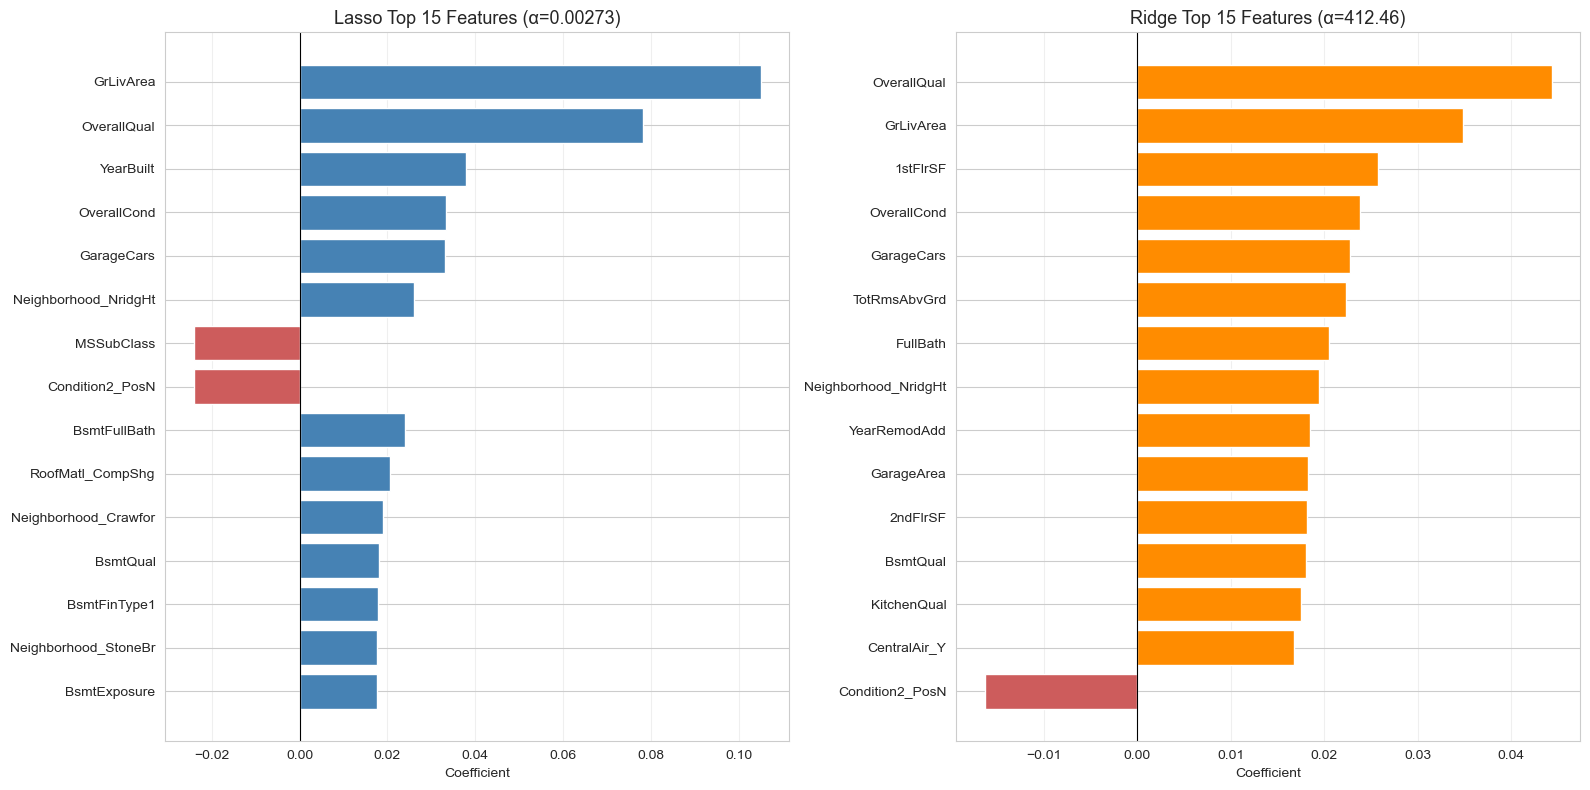

Lasso Top 10 ∩ Ridge Top 10 的共同特征 (5 个):
  • GarageCars
  • GrLivArea
  • Neighborhood_NridgHt
  • OverallCond
  • OverallQual


In [20]:
# ========================================
# Cell 20: Lasso / Ridge 特征重要性对比
# ========================================

# --- Lasso 系数分析 ---
lasso_coef = pd.DataFrame({
    'Feature': X_dev.columns,
    'Coefficient': lasso_best.coef_,
    'AbsCoef': np.abs(lasso_best.coef_)
})
lasso_zero = (lasso_coef['Coefficient'] == 0).sum()
lasso_kept = (lasso_coef['Coefficient'] != 0).sum()

# --- Ridge 系数分析 ---
ridge_coef = pd.DataFrame({
    'Feature': X_dev.columns,
    'Coefficient': ridge_best.coef_,
    'AbsCoef': np.abs(ridge_best.coef_)
})

print("=" * 60)
print(f"  Lasso 特征选择结果（alpha = {best_alpha_lasso:.5f}）")
print("=" * 60)
print(f"  总特征数:           {len(lasso_coef)}")
print(f"  系数被压到 0 的特征:  {lasso_zero} ({lasso_zero/len(lasso_coef)*100:.1f}%)")
print(f"  实际起作用的特征:    {lasso_kept} ({lasso_kept/len(lasso_coef)*100:.1f}%)")
print()

# 画两张图并排：Lasso Top 15 + Ridge Top 15
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- 左：Lasso Top 15 ---
lasso_top15 = lasso_coef[lasso_coef['Coefficient'] != 0].nlargest(15, 'AbsCoef')
colors_lasso = ['steelblue' if c > 0 else 'indianred' for c in lasso_top15['Coefficient']]
axes[0].barh(range(len(lasso_top15)), lasso_top15['Coefficient'], color=colors_lasso)
axes[0].set_yticks(range(len(lasso_top15)))
axes[0].set_yticklabels(lasso_top15['Feature'])
axes[0].invert_yaxis()
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title(f'Lasso Top 15 Features (α={best_alpha_lasso:.5f})', fontsize=13)
axes[0].set_xlabel('Coefficient')
axes[0].grid(True, alpha=0.3, axis='x')

# --- 右：Ridge Top 15 ---
ridge_top15 = ridge_coef.nlargest(15, 'AbsCoef')
colors_ridge = ['darkorange' if c > 0 else 'indianred' for c in ridge_top15['Coefficient']]
axes[1].barh(range(len(ridge_top15)), ridge_top15['Coefficient'], color=colors_ridge)
axes[1].set_yticks(range(len(ridge_top15)))
axes[1].set_yticklabels(ridge_top15['Feature'])
axes[1].invert_yaxis()
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title(f'Ridge Top 15 Features (α={best_alpha_ridge:.2f})', fontsize=13)
axes[1].set_xlabel('Coefficient')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# 打印两个模型 Top 10 的交集
lasso_top10_features = set(lasso_coef[lasso_coef['Coefficient'] != 0].nlargest(10, 'AbsCoef')['Feature'])
ridge_top10_features = set(ridge_coef.nlargest(10, 'AbsCoef')['Feature'])
common = lasso_top10_features & ridge_top10_features

print(f"Lasso Top 10 ∩ Ridge Top 10 的共同特征 ({len(common)} 个):")
for feat in sorted(common):
    print(f"  • {feat}")

## Block 4 小结

这块用正则化方法（Lasso 和 Ridge）对 baseline 做了大幅提升，是整个 project 最关键的一步。

**核心成绩：**

| 模型 | Best Alpha | CV RMSE | Test RMSE | Pct Error |
|---|---|---|---|---|
| Baseline LR | — | 0.1696 | 0.2055 | 22.81% |
| **Lasso** | 0.00273 | 0.1467 | **0.1393** | **14.95%** |
| **Ridge** | 412.46 | 0.1429 | 0.1451 | 15.61% |

Lasso 相对 baseline 提升 32.21%，Ridge 提升 29.41%。误差从 22.81% 降到 15% 左右，对房价预测来说是非常实质性的进步。

**一个反直觉的发现：CV 冠军不一定是 Test 冠军**

Ridge 在 CV 上胜出（0.1429 vs 0.1467），但到 final test 上 Lasso 反而更好（0.1393 vs 0.1451）。回看 alpha 搜索图就能解释：Ridge 的误差带比 Lasso 宽很多，说明 Ridge 对训练集更敏感，泛化到未见数据时波动更大。

这提醒我们不要只看 CV 平均分，**final test 上的表现才是真实泛化能力**。

**Lasso 的特征选择能力**

214 个特征里 Lasso 把 **105 个（49%）直接压到系数 0**，只保留 109 个起作用——等于自动做了特征选择。而效果反而比用全部特征的 Ridge 还好，说明那一半被砍的特征确实是噪音。

**两个模型共同认证的 Top 5 特征：**

- OverallQual（整体品质）
- GrLivArea（居住面积）
- GarageCars（车位数）
- OverallCond（整体状况）
- Neighborhood_NridgHt（NorthRidge 高档社区）

其中 OverallQual 和 GrLivArea 在 Block 1 EDA 阶段就因为相关性最高被预判为关键特征，现在两种正则化方法独立地把它们排在前两位，验证了这个预判。

**一个有意思的细节：L1 和 L2 的选择偏好不同**

Lasso Top 1 是 GrLivArea（面积），Ridge Top 1 是 OverallQual（品质）。这两个特征本身相关性很高，L1 倾向"选其中一个代表"，L2 倾向"两个都保留但都小一点"。这是正则化教科书里 "selection vs shrinkage" 差异的典型案例。

**下一步** 尝试 Gradient Boosting，看看非线性模型能不能进一步压低误差。

In [21]:
# ========================================
# Cell 21: Gradient Boosting 默认参数试跑
# ========================================
from sklearn.ensemble import GradientBoostingRegressor

# 先跑一个完全默认参数的 GB，看看"不调参"的起点在哪
# 注意：GB 不需要标准化特征（它是基于树的，对尺度不敏感）
gb_default = GradientBoostingRegressor(random_state=42)

cv_scores = cross_val_score(
    gb_default, X_dev, y_dev,
    cv=kfold, scoring='neg_mean_squared_error'
)
gb_default_rmse = np.sqrt(-cv_scores).mean()

print("=" * 50)
print("  Gradient Boosting 默认参数 (5-Fold CV)")
print("=" * 50)
print(f"  默认参数: n_estimators=100, learning_rate=0.1, max_depth=3")
print(f"  CV RMSE:  {gb_default_rmse:.4f}")
print("=" * 50)
print("\n和前面模型对比：")
print(f"  Baseline LR:     0.1696")
print(f"  Lasso (best):    0.1467")
print(f"  Ridge (best):    0.1429")
print(f"  GB (默认):       {gb_default_rmse:.4f}")

  Gradient Boosting 默认参数 (5-Fold CV)
  默认参数: n_estimators=100, learning_rate=0.1, max_depth=3
  CV RMSE:  0.1298

和前面模型对比：
  Baseline LR:     0.1696
  Lasso (best):    0.1467
  Ridge (best):    0.1429
  GB (默认):       0.1298


In [22]:
# ========================================
# Cell 22: GridSearchCV 粗筛
# ========================================
from sklearn.model_selection import GridSearchCV

# 粗筛：用小范围快速定位好参数的"邻域"
# 3 * 3 * 3 * 2 = 54 种组合 × 5 fold = 270 次训练，大概 2-3 分钟
param_grid = {
    'n_estimators':  [200, 500, 1000],       # 树的数量
    'learning_rate': [0.01, 0.05, 0.1],      # 学习率
    'max_depth':     [3, 4, 5],              # 树深
    'subsample':     [0.8, 1.0]              # 行采样比例
}

gb_for_grid = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=gb_for_grid,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,      # 用所有 CPU 核心
    verbose=1       # 显示进度
)

print("正在跑 GridSearchCV（54 组参数 × 5 fold = 270 次训练）...")
print("预计 2-3 分钟，请耐心等待。\n")

grid_search.fit(X_dev, y_dev)

# 提取结果
best_grid_params = grid_search.best_params_
best_grid_rmse = np.sqrt(-grid_search.best_score_)

print("\n" + "=" * 50)
print("  GridSearchCV 结果")
print("=" * 50)
print(f"  最佳参数:")
for key, value in best_grid_params.items():
    print(f"    {key}: {value}")
print(f"  最佳 CV RMSE: {best_grid_rmse:.4f}")
print("=" * 50)

正在跑 GridSearchCV（54 组参数 × 5 fold = 270 次训练）...
预计 2-3 分钟，请耐心等待。

Fitting 5 folds for each of 54 candidates, totalling 270 fits

  GridSearchCV 结果
  最佳参数:
    learning_rate: 0.05
    max_depth: 3
    n_estimators: 1000
    subsample: 0.8
  最佳 CV RMSE: 0.1241


In [23]:
# ========================================
# Cell 23: RandomizedSearchCV 细调
# ========================================
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# 细调：在连续空间上随机采 80 个点，能覆盖更广的参数空间
# 多加两个 grid search 没覆盖的参数：min_samples_split、min_samples_leaf
param_dist = {
    'n_estimators':      randint(300, 1500),        # 300 ~ 1500 棵树
    'learning_rate':     uniform(0.01, 0.09),       # 0.01 ~ 0.10
    'max_depth':         randint(3, 7),             # 3 ~ 6
    'subsample':         uniform(0.6, 0.35),        # 0.6 ~ 0.95
    'min_samples_split': randint(2, 20),            # 分裂所需最少样本
    'min_samples_leaf':  randint(1, 10)             # 叶节点最少样本
}

gb_for_random = GradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=gb_for_random,
    param_distributions=param_dist,
    n_iter=80,              # 随机尝试 80 组
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("正在跑 RandomizedSearchCV（80 组随机参数 × 5 fold = 400 次训练）...")
print("预计 5-10 分钟，请耐心等待。\n")

random_search.fit(X_dev, y_dev)

# 提取结果
best_random_params = random_search.best_params_
best_random_rmse = np.sqrt(-random_search.best_score_)
best_gb_model = random_search.best_estimator_   # 后面要用

print("\n" + "=" * 50)
print("  RandomizedSearchCV 结果")
print("=" * 50)
print(f"  最佳参数:")
for key, value in best_random_params.items():
    if isinstance(value, float):
        print(f"    {key}: {value:.4f}")
    else:
        print(f"    {key}: {value}")
print(f"  最佳 CV RMSE: {best_random_rmse:.4f}")
print("=" * 50)

# 对比三个阶段
print("\nGB 三阶段进化：")
print(f"  1. 默认参数:        {gb_default_rmse:.4f}")
print(f"  2. GridSearch 粗筛:  {best_grid_rmse:.4f}")
print(f"  3. RandomSearch 细调: {best_random_rmse:.4f}")

正在跑 RandomizedSearchCV（80 组随机参数 × 5 fold = 400 次训练）...
预计 5-10 分钟，请耐心等待。

Fitting 5 folds for each of 80 candidates, totalling 400 fits

  RandomizedSearchCV 结果
  最佳参数:
    learning_rate: 0.0294
    max_depth: 3
    min_samples_leaf: 7
    min_samples_split: 5
    n_estimators: 1073
    subsample: 0.6181
  最佳 CV RMSE: 0.1227

GB 三阶段进化：
  1. 默认参数:        0.1298
  2. GridSearch 粗筛:  0.1241
  3. RandomSearch 细调: 0.1227


计算 max_depth 的 validation curve...
计算 learning_rate 的 validation curve...
计算 n_estimators 的 validation curve...


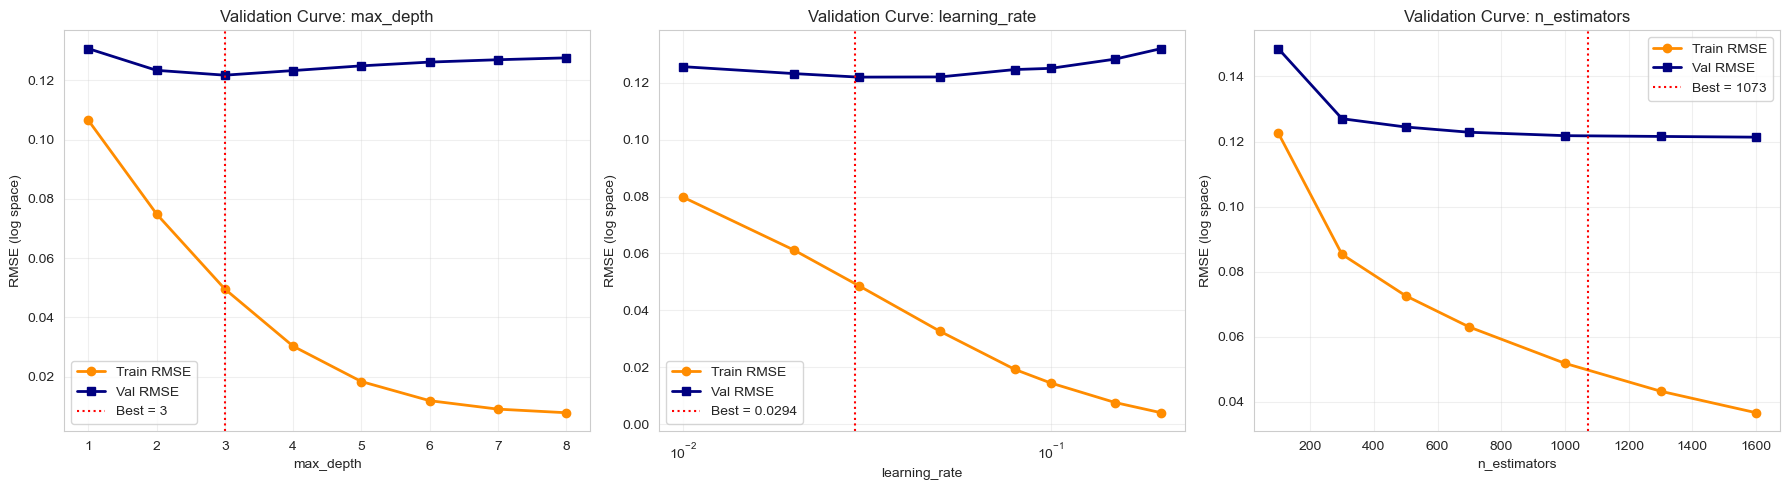


✓ 三个关键参数的 validation curve 绘制完成


In [24]:
# ========================================
# Cell 24: Validation Curves (三个关键参数)
# ========================================
from sklearn.model_selection import validation_curve

# 以 RandomSearch 找到的最佳参数为"基准"，每次只改一个参数看变化
# 这样能隔离出每个参数的单独影响
base_params = {
    'learning_rate': best_random_params['learning_rate'],
    'max_depth': best_random_params['max_depth'],
    'n_estimators': best_random_params['n_estimators'],
    'subsample': best_random_params['subsample'],
    'min_samples_leaf': best_random_params['min_samples_leaf'],
    'min_samples_split': best_random_params['min_samples_split'],
    'random_state': 42
}

# 用 3 行 1 列的画布并排展示
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ========== 图 1: max_depth ==========
print("计算 max_depth 的 validation curve...")
depth_range = np.arange(1, 9)
params_for_depth = {k: v for k, v in base_params.items() if k != 'max_depth'}
train_scores, val_scores = validation_curve(
    GradientBoostingRegressor(**params_for_depth),
    X_dev, y_dev,
    param_name='max_depth',
    param_range=depth_range,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
train_rmse = np.sqrt(-train_scores).mean(axis=1)
val_rmse = np.sqrt(-val_scores).mean(axis=1)

axes[0].plot(depth_range, train_rmse, 'o-', color='darkorange', label='Train RMSE', lw=2)
axes[0].plot(depth_range, val_rmse, 's-', color='navy', label='Val RMSE', lw=2)
axes[0].axvline(x=base_params['max_depth'], color='red', linestyle=':',
                label=f"Best = {base_params['max_depth']}")
axes[0].set_title('Validation Curve: max_depth', fontsize=12)
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('RMSE (log space)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ========== 图 2: learning_rate ==========
print("计算 learning_rate 的 validation curve...")
lr_range = np.array([0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2])
params_for_lr = {k: v for k, v in base_params.items() if k != 'learning_rate'}
train_scores, val_scores = validation_curve(
    GradientBoostingRegressor(**params_for_lr),
    X_dev, y_dev,
    param_name='learning_rate',
    param_range=lr_range,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
train_rmse = np.sqrt(-train_scores).mean(axis=1)
val_rmse = np.sqrt(-val_scores).mean(axis=1)

axes[1].plot(lr_range, train_rmse, 'o-', color='darkorange', label='Train RMSE', lw=2)
axes[1].plot(lr_range, val_rmse, 's-', color='navy', label='Val RMSE', lw=2)
axes[1].axvline(x=base_params['learning_rate'], color='red', linestyle=':',
                label=f"Best = {base_params['learning_rate']:.4f}")
axes[1].set_title('Validation Curve: learning_rate', fontsize=12)
axes[1].set_xlabel('learning_rate')
axes[1].set_ylabel('RMSE (log space)')
axes[1].set_xscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ========== 图 3: n_estimators ==========
print("计算 n_estimators 的 validation curve...")
n_range = np.array([100, 300, 500, 700, 1000, 1300, 1600])
params_for_n = {k: v for k, v in base_params.items() if k != 'n_estimators'}
train_scores, val_scores = validation_curve(
    GradientBoostingRegressor(**params_for_n),
    X_dev, y_dev,
    param_name='n_estimators',
    param_range=n_range,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
train_rmse = np.sqrt(-train_scores).mean(axis=1)
val_rmse = np.sqrt(-val_scores).mean(axis=1)

axes[2].plot(n_range, train_rmse, 'o-', color='darkorange', label='Train RMSE', lw=2)
axes[2].plot(n_range, val_rmse, 's-', color='navy', label='Val RMSE', lw=2)
axes[2].axvline(x=base_params['n_estimators'], color='red', linestyle=':',
                label=f"Best = {base_params['n_estimators']}")
axes[2].set_title('Validation Curve: n_estimators', fontsize=12)
axes[2].set_xlabel('n_estimators')
axes[2].set_ylabel('RMSE (log space)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ 三个关键参数的 validation curve 绘制完成")

In [25]:
# ========================================
# Cell 25: 最佳 GB 在 Final Test 上的表现
# ========================================

# best_gb_model 是 RandomSearch 留下来的最佳模型，已经在整个 dev set 上训练过了
# 直接用它预测 final test
gb_test_pred = best_gb_model.predict(X_test)
gb_test_rmse = rmse(y_test, gb_test_pred)
gb_pct_error = (np.exp(gb_test_rmse) - 1) * 100

print("=" * 50)
print("  Gradient Boosting - Final Test")
print("=" * 50)
print(f"  Test RMSE:  {gb_test_rmse:.4f}")
print(f"  百分比误差:  {gb_pct_error:.2f}%")
print("=" * 50)

# 更新完整排名表
full_summary = pd.DataFrame({
    'Model':     ['Baseline LR', 'Lasso',        'Ridge',       'GB (default)',  'GB (tuned)'],
    'CV RMSE':   [baseline_cv_rmse, best_rmse_lasso, best_rmse_ridge, gb_default_rmse, best_random_rmse],
    'Test RMSE': [baseline_test_rmse, lasso_test_rmse, ridge_test_rmse, np.nan, gb_test_rmse],
    'Pct Error': [f'{(np.exp(baseline_test_rmse)-1)*100:.2f}%',
                  f'{(np.exp(lasso_test_rmse)-1)*100:.2f}%',
                  f'{(np.exp(ridge_test_rmse)-1)*100:.2f}%',
                  '—',
                  f'{gb_pct_error:.2f}%']
})
full_summary['CV RMSE'] = full_summary['CV RMSE'].round(4)
full_summary['Test RMSE'] = full_summary['Test RMSE'].round(4)

print("\n" + "=" * 70)
print("  完整模型对比（目前为止）")
print("=" * 70)
print(full_summary.to_string(index=False))
print("=" * 70)

# 相对 baseline 的提升
gb_improvement = (baseline_test_rmse - gb_test_rmse) / baseline_test_rmse * 100
print(f"\n🏆 GB (tuned) 相对 Baseline 的 Test RMSE 提升: ↓ {gb_improvement:.2f}%")

  Gradient Boosting - Final Test
  Test RMSE:  0.1362
  百分比误差:  14.59%

  完整模型对比（目前为止）
       Model  CV RMSE  Test RMSE Pct Error
 Baseline LR   0.1696     0.2055    22.81%
       Lasso   0.1467     0.1393    14.95%
       Ridge   0.1429     0.1451    15.61%
GB (default)   0.1298        NaN         —
  GB (tuned)   0.1227     0.1362    14.59%

🏆 GB (tuned) 相对 Baseline 的 Test RMSE 提升: ↓ 33.71%


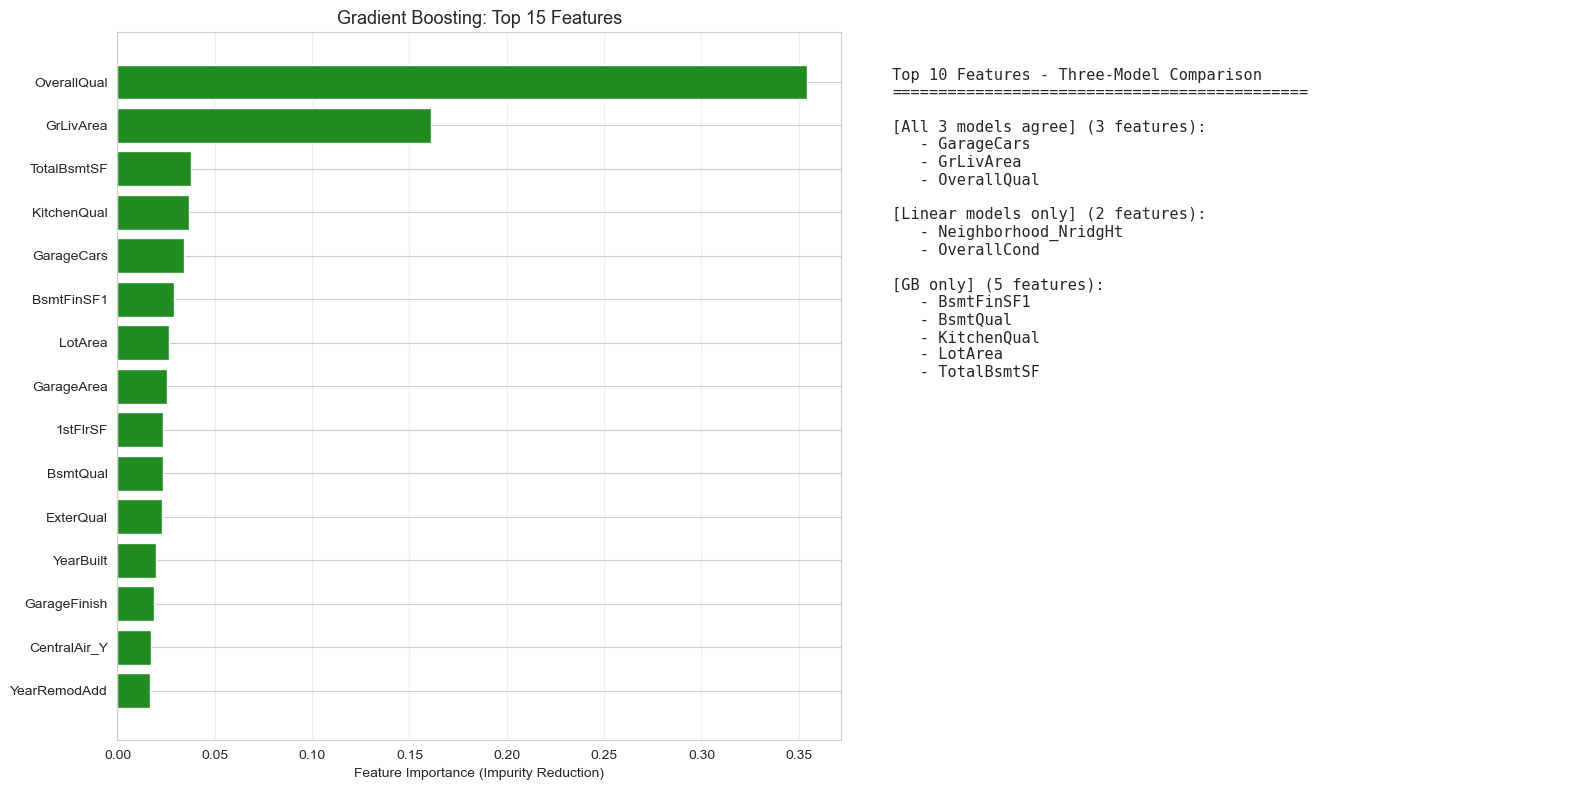


Feature importance comparison done.


In [26]:
# ========================================
# Cell 26: GB Feature Importance + 三模型对比
# ========================================

# GB 的 feature_importances_ 是基于"分裂时降低的不纯度"
gb_importance = pd.DataFrame({
    'Feature': X_dev.columns,
    'Importance': best_gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- 左图：GB Top 15 ---
gb_top15 = gb_importance.head(15)
axes[0].barh(range(len(gb_top15)), gb_top15['Importance'], color='forestgreen')
axes[0].set_yticks(range(len(gb_top15)))
axes[0].set_yticklabels(gb_top15['Feature'])
axes[0].invert_yaxis()
axes[0].set_title('Gradient Boosting: Top 15 Features', fontsize=13)
axes[0].set_xlabel('Feature Importance (Impurity Reduction)')
axes[0].grid(True, alpha=0.3, axis='x')

# --- 右图：三模型 Top 10 交集 ---
lasso_top10 = set(lasso_coef[lasso_coef['Coefficient'] != 0].nlargest(10, 'AbsCoef')['Feature'])
ridge_top10 = set(ridge_coef.nlargest(10, 'AbsCoef')['Feature'])
gb_top10    = set(gb_importance.head(10)['Feature'])

all_three = lasso_top10 & ridge_top10 & gb_top10
lasso_ridge_only = (lasso_top10 & ridge_top10) - gb_top10
only_gb = gb_top10 - lasso_top10 - ridge_top10

axes[1].axis('off')
summary_text = "Top 10 Features - Three-Model Comparison\n" + "=" * 45 + "\n\n"
summary_text += f"[All 3 models agree] ({len(all_three)} features):\n"
for f in sorted(all_three):
    summary_text += f"   - {f}\n"
summary_text += f"\n[Linear models only] ({len(lasso_ridge_only)} features):\n"
for f in sorted(lasso_ridge_only):
    summary_text += f"   - {f}\n"
summary_text += f"\n[GB only] ({len(only_gb)} features):\n"
for f in sorted(only_gb):
    summary_text += f"   - {f}\n"

axes[1].text(0.05, 0.95, summary_text, fontsize=11, family='monospace',
             verticalalignment='top', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

print("\nFeature importance comparison done.")

## Block 5 小结

这块引入 Gradient Boosting，并通过三阶段调参把误差压到目前最低。

**GB 三阶段进化：**

| 阶段 | CV RMSE | 说明 |
|---|---|---|
| 1. 默认参数 | 0.1298 | 开箱即用已经超过最好的线性模型 |
| 2. GridSearchCV 粗筛 | 0.1241 | 54 组参数粗扫 |
| 3. RandomizedSearchCV 细调 | **0.1227** | 80 组随机采样，6 个参数 |

RandomSearch 找到的最佳组合：
- `learning_rate = 0.0294`（小学习率）
- `max_depth = 3`（浅树）
- `n_estimators = 1073`（多棵树）
- `subsample = 0.6181`（高随机性）
- `min_samples_leaf = 7`, `min_samples_split = 5`

这个组合体现了经典的"防过拟合策略"：每棵树学一点点、用更多棵树慢慢叠加、每次只用 62% 的数据打破相关性。

**Validation Curve 分析：**

对三个关键参数单独画 validation curve，得到三个典型图形：

- `max_depth` 图是经典的过拟合曲线——训练误差随深度单调下降但验证误差在 depth=3 后平稳，深度更大只是在记忆训练集
- `learning_rate` 图呈 U 形——0.01 欠拟合、0.2 过拟合，0.0294 正好在甜点
- `n_estimators` 图在 n=300 后就进入边际效益递减区，n=1073 vs n=400 的验证误差只差 0.001，实际部署可以用更少的树节省资源

**Final Test 结果：**

| 模型 | Test RMSE | Pct Error |
|---|---|---|
| Baseline LR | 0.2055 | 22.81% |
| Lasso | 0.1393 | 14.95% |
| Ridge | 0.1451 | 15.61% |
| **GB (tuned)** | **0.1362** | **14.59%** |

GB tuned 是 Test 榜单第一，但只比 Lasso 低 0.003。Lasso 以更简单的模型 + 自动特征选择达到了接近 GB 的水平，这也反映了好的特征工程比模型本身更重要。

**特征重要性的三模型对比：**

- **三模型都认可（3 个）**：OverallQual、GrLivArea、GarageCars。三种完全不同原理的算法独立选出的特征，可信度最高。
- **仅线性模型**（2 个）：Neighborhood_NridgHt、OverallCond。线性模型倾向于把"高价地段标签"作为独立因素。
- **仅 GB**（5 个）：BsmtFinSF1、BsmtQual、KitchenQual、LotArea、TotalBsmtSF——全是连续面积/品质特征。GB 擅长在连续值上切阈值，捕捉非线性关系。

这揭示了一个深层差异：**线性模型看到"什么标签对应高价"，GB 看到"造成高价的物理本质"**。比如 GB 没把 NridgHt 放进 Top 10，是因为 OverallQual + GrLivArea 的组合已经隐式捕捉了"高档社区房屋品质更高、面积更大"这层关系——GB 不需要再单独给社区标签分重要性。

**下一步** 进入 Block 6，做最终模型对比汇总、画整体可视化、写 project 结论。

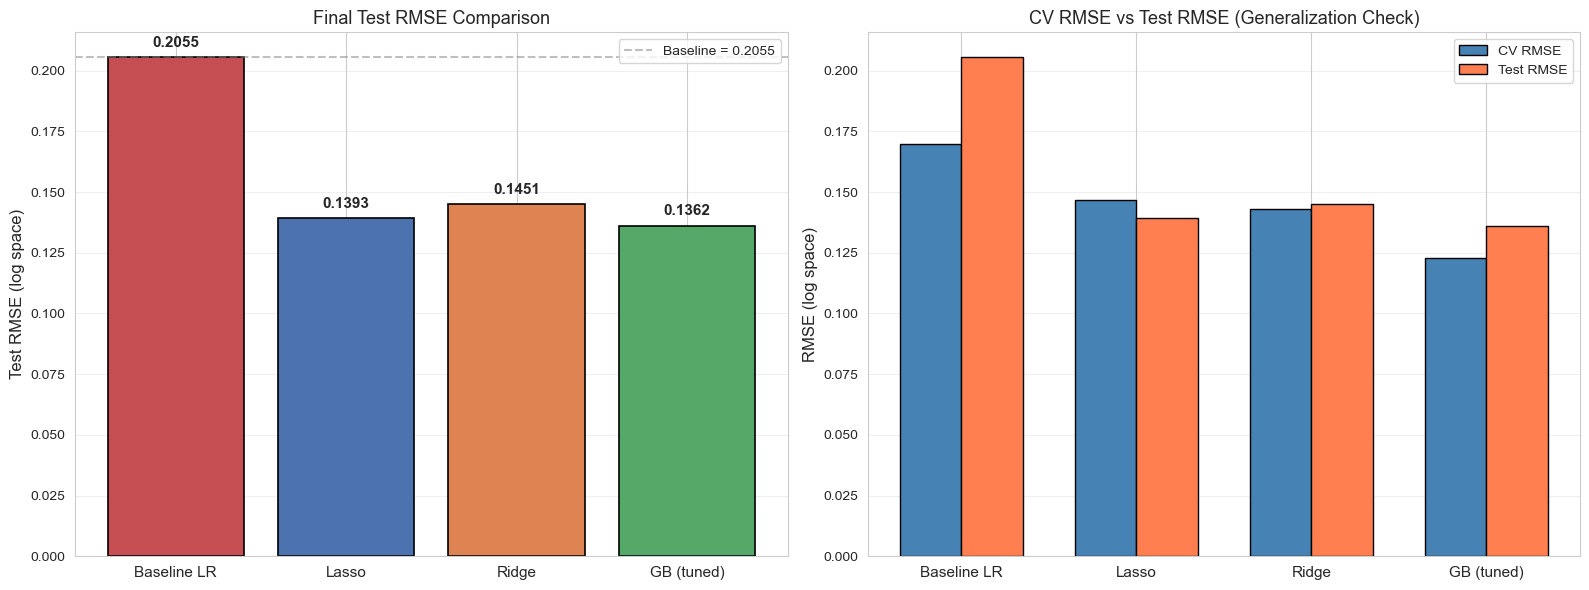


  FINAL MODEL COMPARISON
      Model  CV RMSE  Test RMSE Pct Error vs Baseline
Baseline LR   0.1696     0.2055    22.81%     ↓ 0.00%
      Lasso   0.1467     0.1393    14.95%    ↓ 32.21%
      Ridge   0.1429     0.1451    15.61%    ↓ 29.41%
 GB (tuned)   0.1227     0.1362    14.59%    ↓ 33.71%


In [27]:
# ========================================
# Cell 27: 所有模型 Test RMSE 总览
# ========================================

# 汇总所有有 Test RMSE 的模型
models = ['Baseline LR', 'Lasso', 'Ridge', 'GB (tuned)']
test_rmses = [baseline_test_rmse, lasso_test_rmse, ridge_test_rmse, gb_test_rmse]
cv_rmses = [baseline_cv_rmse, best_rmse_lasso, best_rmse_ridge, best_random_rmse]

# 画对比图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 左图：Test RMSE 条形图（从大到小排列，视觉上从 baseline 降到 best） ---
x_pos = np.arange(len(models))
colors = ['#C44E52', '#4C72B0', '#DD8452', '#55A868']  # 红 蓝 橙 绿

bars = axes[0].bar(x_pos, test_rmses, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, fontsize=11)
axes[0].set_ylabel('Test RMSE (log space)', fontsize=12)
axes[0].set_title('Final Test RMSE Comparison', fontsize=13)
axes[0].grid(True, alpha=0.3, axis='y')

# 在每个柱子上标数字
for bar, rmse_val in zip(bars, test_rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{rmse_val:.4f}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# 加一条 baseline 水平线作为参照
axes[0].axhline(y=baseline_test_rmse, color='gray', linestyle='--',
                alpha=0.5, label=f'Baseline = {baseline_test_rmse:.4f}')
axes[0].legend()

# --- 右图：CV vs Test 对比（验证泛化能力） ---
width = 0.35
axes[1].bar(x_pos - width/2, cv_rmses, width, label='CV RMSE', color='steelblue', edgecolor='black')
axes[1].bar(x_pos + width/2, test_rmses, width, label='Test RMSE', color='coral', edgecolor='black')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, fontsize=11)
axes[1].set_ylabel('RMSE (log space)', fontsize=12)
axes[1].set_title('CV RMSE vs Test RMSE (Generalization Check)', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 打印最终汇总表
print("\n" + "=" * 70)
print("  FINAL MODEL COMPARISON")
print("=" * 70)
final_summary = pd.DataFrame({
    'Model':     models,
    'CV RMSE':   [round(x, 4) for x in cv_rmses],
    'Test RMSE': [round(x, 4) for x in test_rmses],
    'Pct Error': [f'{(np.exp(x)-1)*100:.2f}%' for x in test_rmses],
    'vs Baseline': [f'↓ {(baseline_test_rmse-x)/baseline_test_rmse*100:.2f}%' for x in test_rmses]
})
print(final_summary.to_string(index=False))
print("=" * 70)

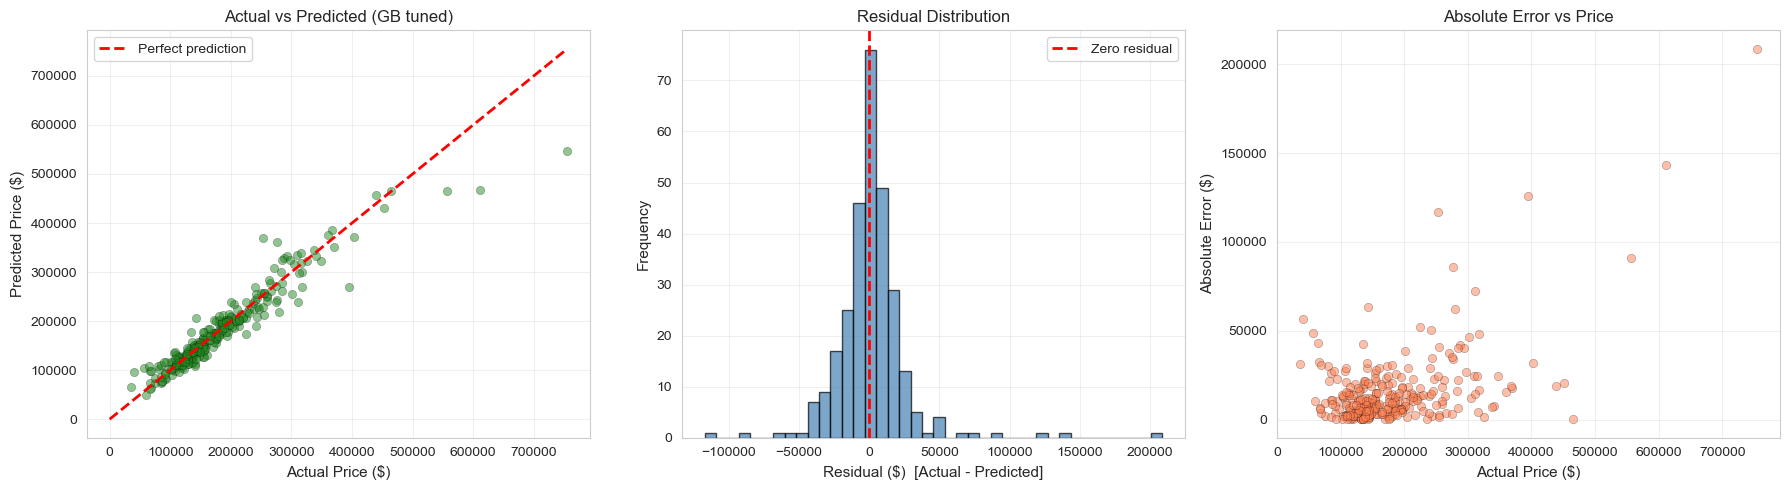

  Residual Analysis (GB tuned, on Final Test)
  Mean residual:           $       1,467
  Median residual:         $       1,134
  Mean absolute error:     $      15,409
  Median absolute error:   $       9,666
  Max absolute error:      $     208,642

  Top 5 worst predictions:
        Actual     Predicted         Error


IndexError: index 691 is out of bounds for axis 0 with size 292

In [28]:
# ========================================
# Cell 28: Best Model (GB tuned) 残差分析
# ========================================

# 用 GB tuned 在 test 上的预测做分析
# 注意：y_test 是 log 空间的，先还原回美元空间再分析残差，更直观
y_test_dollar = np.expm1(y_test)
gb_pred_dollar = np.expm1(gb_test_pred)
residuals_dollar = y_test_dollar - gb_pred_dollar
abs_residuals = np.abs(residuals_dollar)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 图 1: Actual vs Predicted 散点图 ---
axes[0].scatter(y_test_dollar, gb_pred_dollar, alpha=0.5, color='forestgreen', edgecolor='black', linewidth=0.3)
max_val = max(y_test_dollar.max(), gb_pred_dollar.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=11)
axes[0].set_ylabel('Predicted Price ($)', fontsize=11)
axes[0].set_title('Actual vs Predicted (GB tuned)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- 图 2: 残差分布直方图 ---
axes[1].hist(residuals_dollar, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2, label='Zero residual')
axes[1].set_xlabel('Residual ($)  [Actual - Predicted]', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Residual Distribution', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- 图 3: 误差 vs 价格（看模型在不同价位上的表现） ---
axes[2].scatter(y_test_dollar, abs_residuals, alpha=0.5, color='coral', edgecolor='black', linewidth=0.3)
axes[2].set_xlabel('Actual Price ($)', fontsize=11)
axes[2].set_ylabel('Absolute Error ($)', fontsize=11)
axes[2].set_title('Absolute Error vs Price', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 残差的数字统计
print("=" * 55)
print("  Residual Analysis (GB tuned, on Final Test)")
print("=" * 55)
print(f"  Mean residual:           ${residuals_dollar.mean():>12,.0f}")
print(f"  Median residual:         ${residuals_dollar.median():>12,.0f}")
print(f"  Mean absolute error:     ${abs_residuals.mean():>12,.0f}")
print(f"  Median absolute error:   ${abs_residuals.median():>12,.0f}")
print(f"  Max absolute error:      ${abs_residuals.max():>12,.0f}")
print("=" * 55)

# 找出预测最差的 5 套房
worst_5_idx = abs_residuals.nlargest(5).index
print("\n  Top 5 worst predictions:")
print(f"  {'Actual':>12}  {'Predicted':>12}  {'Error':>12}")
for idx in worst_5_idx:
    act = y_test_dollar[idx]
    pred = gb_pred_dollar[idx]
    err = act - pred
    print(f"  ${act:>10,.0f}   ${pred:>10,.0f}   ${err:>+10,.0f}")

In [29]:
# ========================================
# Cell 28b: 修复 Top 5 最差预测的打印
# ========================================

# 把 y_test / gb_pred 重置为 numpy array，避免索引错位
y_test_arr = y_test_dollar.values
gb_pred_arr = gb_pred_dollar  # 已经是 array
residuals_arr = y_test_arr - gb_pred_arr
abs_resid_arr = np.abs(residuals_arr)

# 按绝对误差降序，取 Top 5
worst_5 = np.argsort(abs_resid_arr)[-5:][::-1]

print("  Top 5 worst predictions:")
print(f"  {'Actual':>12}  {'Predicted':>12}  {'Error':>12}  {'% Error':>8}")
print("  " + "-" * 50)
for idx in worst_5:
    act = y_test_arr[idx]
    pred = gb_pred_arr[idx]
    err = act - pred
    pct = err / act * 100
    print(f"  ${act:>10,.0f}   ${pred:>10,.0f}   ${err:>+10,.0f}   {pct:>+7.1f}%")

  Top 5 worst predictions:
        Actual     Predicted         Error   % Error
  --------------------------------------------------
  $   755,000   $   546,358   $  +208,642     +27.6%
  $   611,657   $   468,322   $  +143,335     +23.4%
  $   395,000   $   268,934   $  +126,066     +31.9%
  $   253,293   $   370,372   $  -117,079     -46.2%
  $   556,581   $   465,552   $   +91,029     +16.4%


In [30]:
# ========================================
# Cell 29: Project 整体结论
# ========================================

print("=" * 70)
print("  HOUSE PRICE PREDICTION - PROJECT SUMMARY")
print("=" * 70)
print(f"""
Dataset:        Ames Housing (1460 samples × 79 features, 2006-2010 Iowa)
Target:         log(1 + SalePrice)
Split:          80% dev (1168) / 20% final test (292)
Evaluation:     RMSE in log space (Kaggle official metric)

--- Performance Progression ---

    Baseline LR        →  Test RMSE 0.2055  (22.81% error)
    + L1 regularization →  Test RMSE 0.1393  (14.95% error)  [Lasso]
    + L2 regularization →  Test RMSE 0.1451  (15.61% error)  [Ridge]
    + Gradient Boosting →  Test RMSE 0.1362  (14.59% error)  [Best]

    Total improvement: 33.71% reduction in Test RMSE

--- Key Takeaways ---

1. DATA ENGINEERING > MODEL COMPLEXITY
   Careful missing-value diagnosis (15 "None" cols + 1 mode col + 
   neighborhood-median LotFrontage) + ordinal encoding for quality 
   features was critical. Without these, even GB struggles.

2. THREE MODELS CONVERGE ON 3 CORE FEATURES
   OverallQual, GrLivArea, GarageCars are selected by L1, L2, and 
   tree-based methods independently. These are the most trustworthy 
   predictors of Ames house prices.

3. LINEAR vs TREE MODELS SEE DIFFERENT THINGS
   Linear models value neighborhood labels (Neighborhood_NridgHt) as 
   independent price premiums. GB captures the same signal implicitly 
   through quality × size interactions, so it doesn't need the label.

4. SIMPLE MODELS ARE COMPETITIVE
   Lasso (0.1393) is only 0.003 behind GB tuned (0.1362). If 
   interpretability or compute efficiency matters, Lasso is a strong 
   choice — 50%% of features can be dropped with minimal accuracy loss.

5. HIGH-PRICE HOMES ARE HARDER TO PREDICT
   Residual analysis shows error magnitude scales with price. 
   Luxury homes (>$400K) have few training examples and more 
   idiosyncratic pricing — this is a known limitation of the dataset.
""")
print("=" * 70)

  HOUSE PRICE PREDICTION - PROJECT SUMMARY

Dataset:        Ames Housing (1460 samples × 79 features, 2006-2010 Iowa)
Target:         log(1 + SalePrice)
Split:          80% dev (1168) / 20% final test (292)
Evaluation:     RMSE in log space (Kaggle official metric)

--- Performance Progression ---

    Baseline LR        →  Test RMSE 0.2055  (22.81% error)
    + L1 regularization →  Test RMSE 0.1393  (14.95% error)  [Lasso]
    + L2 regularization →  Test RMSE 0.1451  (15.61% error)  [Ridge]
    + Gradient Boosting →  Test RMSE 0.1362  (14.59% error)  [Best]

    Total improvement: 33.71% reduction in Test RMSE

--- Key Takeaways ---

1. DATA ENGINEERING > MODEL COMPLEXITY
   Careful missing-value diagnosis (15 "None" cols + 1 mode col + 
   neighborhood-median LotFrontage) + ordinal encoding for quality 
   features was critical. Without these, even GB struggles.

2. THREE MODELS CONVERGE ON 3 CORE FEATURES
   OverallQual, GrLivArea, GarageCars are selected by L1, L2, and 
   tree-bas